CRIME DATASET ANALYSIS FOR LOGISTIC REGRESSION
Dataset Shape: (5000, 11)

Missing Values:
City                    0
Area_Code               0
Population              0
Unemployment_Rate       0
Police_Stations         0
Time                    0
Victim_Age              0
Victim_Gender           0
Weapon_Used          1230
Past_Crime_Rate         0
Crime_Occurred          0
dtype: int64

Target Distribution:
Crime_Occurred
0    2750
1    2250
Name: count, dtype: int64
Target Ratio: 45.00%
✅ Encoded City: 10 unique values
✅ Encoded Time: 4 unique values
✅ Encoded Victim_Gender: 2 unique values
✅ Encoded Weapon_Used: 4 unique values

📊 Feature Correlation with Target:
  Past_Crime_Rate: 0.661
  Unemployment_Rate: 0.358
  Time: 0.035
  Victim_Gender: 0.018
  City: 0.016
  Population: 0.015
  Victim_Age: 0.010
  Area_Code: -0.038
  Police_Stations: -0.170
  Weapon_Used: -0.278

MODEL EVALUATION RESULTS
✅ Accuracy: 0.9620
✅ ROC-AUC Score: 0.9957
✅ Cross-validation Score (5-fold): 0.9643

Cla

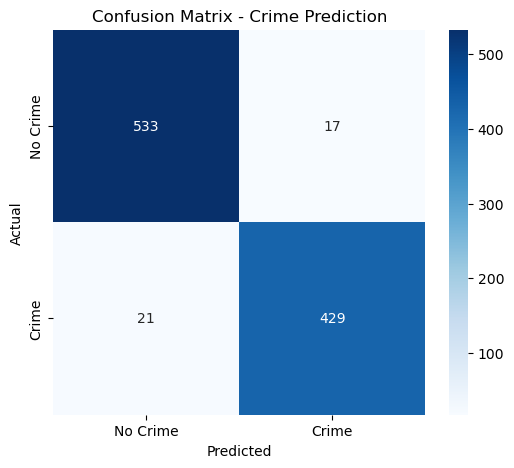

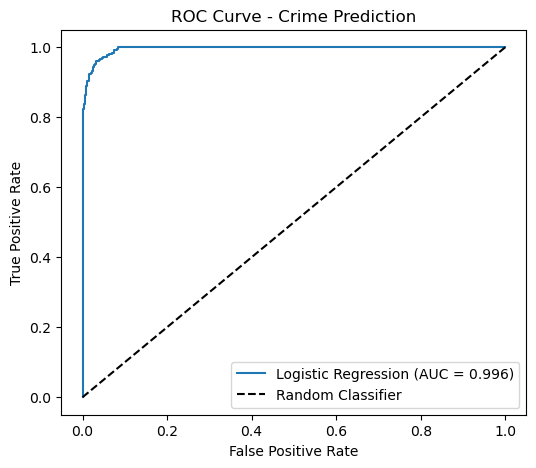


📈 Feature Importance (Top 10):
  Past_Crime_Rate: 8.0929
  Unemployment_Rate: 4.7738
  Weapon_Used: -3.8181
  Police_Stations: -2.4280
  Time: 0.4809
  Population: 0.0943
  Victim_Age: 0.0940
  Victim_Gender: 0.0710
  City: -0.0446
  Area_Code: 0.0207

✅ Model, scaler, and encoders saved successfully!
   - crime_model.pkl
   - crime_scaler.pkl
   - crime_label_encoders.pkl


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Load crime dataset - CSV file
df_crime = pd.read_csv('crime dataset.csv')

print("="*50)
print("CRIME DATASET ANALYSIS FOR LOGISTIC REGRESSION")
print("="*50)
print(f"Dataset Shape: {df_crime.shape}")
print(f"\nMissing Values:\n{df_crime.isnull().sum()}")
print(f"\nTarget Distribution:")
print(df_crime['Crime_Occurred'].value_counts())
print(f"Target Ratio: {df_crime['Crime_Occurred'].mean():.2%}")

# Check for class imbalance
class_0, class_1 = df_crime['Crime_Occurred'].value_counts()
if class_0 < class_1 * 0.8 or class_1 < class_0 * 0.8:
    print("\n⚠️ Warning: Class imbalance detected! Consider using class_weight='balanced'")

# Encode categorical columns
le_dict = {}  # Store label encoders for each column
categorical_cols = ['City', 'Time', 'Victim_Gender', 'Weapon_Used']

for col in categorical_cols:
    if col in df_crime.columns:
        le = LabelEncoder()
        df_crime[col] = le.fit_transform(df_crime[col].astype(str))
        le_dict[col] = le  # Save encoder for future use
        print(f"✅ Encoded {col}: {len(le.classes_)} unique values")

# Features and target
feature_cols = ['City', 'Area_Code', 'Population', 'Unemployment_Rate', 
                'Police_Stations', 'Time', 'Victim_Age', 'Victim_Gender', 
                'Weapon_Used', 'Past_Crime_Rate']

X = df_crime[feature_cols]
y = df_crime['Crime_Occurred']

# Check correlation with target
print("\n📊 Feature Correlation with Target:")
correlations = X.corrwith(y).sort_values(ascending=False)
for feature, corr in correlations.items():
    print(f"  {feature}: {corr:.3f}")

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression with class_weight='balanced' for imbalanced data
crime_model = LogisticRegression(
    max_iter=1000, 
    random_state=42,
    class_weight='balanced',  # Handles class imbalance automatically
    C=1.0  # Regularization strength (can tune this)
)
crime_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = crime_model.predict(X_test_scaled)
y_pred_proba = crime_model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "="*50)
print("MODEL EVALUATION RESULTS")
print("="*50)
print(f"✅ Accuracy: {accuracy:.4f}")
print(f"✅ ROC-AUC Score: {roc_auc:.4f}")
print(f"✅ Cross-validation Score (5-fold): {cross_val_score(crime_model, X_train_scaled, y_train, cv=5).mean():.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Crime', 'Crime'], 
            yticklabels=['No Crime', 'Crime'])
plt.title('Confusion Matrix - Crime Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('crime_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# ROC Curve
plt.figure(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Crime Prediction')
plt.legend()
plt.savefig('crime_roc_curve.png', dpi=100, bbox_inches='tight')
plt.show()

# Feature importance (coefficients)
print("\n📈 Feature Importance (Top 10):")
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': crime_model.coef_[0]
})
coefficients['Abs_Coefficient'] = np.abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values('Abs_Coefficient', ascending=False)
for i, row in coefficients.head(10).iterrows():
    print(f"  {row['Feature']}: {row['Coefficient']:.4f}")

# Save model and scaler
joblib.dump(crime_model, 'crime_model.pkl')
joblib.dump(scaler, 'crime_scaler.pkl')
joblib.dump(le_dict, 'crime_label_encoders.pkl')  # Save encoders too

print("\n✅ Model, scaler, and encoders saved successfully!")
print("   - crime_model.pkl")
print("   - crime_scaler.pkl")
print("   - crime_label_encoders.pkl")